# Cargamos las Bibliotecas

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import fastparquet
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Lectura de los archivos a ocupar 
**especificando las columnas(variables) que se utilizaran**

- #### personas_censo2024: 
`id_vivienda`, `id_hogar`, `id_persona`, `sexo`, `edad`, `p27_nacionalidad`, `p27_nacionalidad_esp`, `p27_nacionalidad_rec`, `p24_lug_resid5`, `p24_lug_resid5_esp`, `p25_lug_nacimiento`, `p25_lug_nacimiento_rec`, `p26_llegada_periodo`, `escolaridad`, `cine11`, `sit_fuerza_trabajo`, `cod_ciuo`, `cod_caenes`, `p45_medio_transporte`

- #### viviendas_censo2024: 
`id_vivienda`, `region`, `comuna`, `p4a_mat_paredes`, `p4b_mat_techo`, `p4c_mat_piso`

- #### hogares_censo2024: 
`id_vivienda`, `id_hogar`, `p12_tenencia_viv`, `tipologia_hogar`

In [2]:
personas = pd.read_parquet("personas_censo2024.parquet", engine="fastparquet", columns= ["id_vivienda", "id_hogar", "id_persona", "sexo", "edad",
"p27_nacionalidad","p27_nacionalidad_esp", "p27_nacionalidad_rec", "p24_lug_resid5","p24_lug_resid5_esp", "p25_lug_nacimiento","p25_lug_nacimiento_rec", "p26_llegada_periodo", "escolaridad", "cine11", "sit_fuerza_trabajo",
"cod_ciuo", "cod_caenes", "p45_medio_transporte"])

personas

,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad,p27_nacionalidad_esp,p27_nacionalidad_rec,p24_lug_resid5,p24_lug_resid5_esp,p25_lug_nacimiento,p25_lug_nacimiento_rec,p26_llegada_periodo,escolaridad,cine11,sit_fuerza_trabajo,cod_ciuo,cod_caenes,p45_medio_transporte
0,1,1,1,2,80,1,152,1,3,13117.0,2,1,NaN,17,9,3.0,NaN,None,NaN
1,1,1,2,1,52,1,152,1,2,5802.0,2,1,NaN,14,6,1.0,7.0,F,2.0
2,1,1,3,2,45,1,152,1,2,5802.0,2,1,NaN,12,6,1.0,2.0,P,3.0
3,1,1,4,2,8,1,152,1,2,5802.0,1,1,NaN,2,3,NaN,NaN,None,NaN
4,2,1,1,1,69,1,152,1,3,4301.0,2,1,NaN,12,6,3.0,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18480427,7664466,1,2,1,31,1,152,1,2,13122.0,2,1,NaN,10,5,1.0,999.0,G,4.0
18480428,7664466,1,3,1,24,1,152,1,2,13122.0,1,1,NaN,17,6,3.0,NaN,None,NaN
18480429,7664466,1,4,2,34,1,152,1,2,13122.0,2,1,NaN,12,6,1.0,4.0,J,7.0
18480430,7664466,1,5,1,2,1,152,1,1,NaN,1,1,NaN,0,1,NaN,NaN,None,NaN


In [3]:
viviendas = pd.read_parquet("viviendas_censo2024.parquet", engine="fastparquet", columns=["id_vivienda", "region", "comuna", 'p4a_mat_paredes',
       'p4b_mat_techo', 'p4c_mat_piso'])

viviendas

,id_vivienda,region,comuna,p4a_mat_paredes,p4b_mat_techo,p4c_mat_piso
0,1,5,5802,5.0,1.0,2.0
1,2,4,4303,2.0,3.0,3.0
2,3,11,11202,2.0,3.0,1.0
3,4,1,1101,1.0,2.0,1.0
4,5,8,8301,2.0,3.0,1.0
...,...,...,...,...,...,...
7664461,7664462,3,3101,2.0,4.0,1.0
7664462,7664463,14,14202,3.0,3.0,1.0
7664463,7664464,9,9105,3.0,3.0,1.0
7664464,7664465,5,5101,1.0,3.0,1.0


In [4]:
hogares = pd.read_parquet("hogares_censo2024.parquet", engine="fastparquet", columns=['id_vivienda','id_hogar','p12_tenencia_viv','tipologia_hogar'])

hogares

,id_vivienda,id_hogar,p12_tenencia_viv,tipologia_hogar
0,1,1,4.0,5.0
1,2,1,9.0,7.0
2,3,1,3.0,4.0
3,4,1,3.0,4.0
4,5,1,1.0,1.0
...,...,...,...,...
6622592,7664462,1,2.0,4.0
6622593,7664463,1,4.0,1.0
6622594,7664464,1,1.0,1.0
6622595,7664465,1,1.0,2.0


In [5]:
OUR_COMUNAS = [13107, 13112, 13502, 13504, 13602]

In [6]:
viv = viviendas[viviendas["comuna"].isin(OUR_COMUNAS)]
hog = hogares[hogares["id_vivienda"].isin(viv["id_vivienda"])]
per = personas[personas["id_vivienda"].isin(viv["id_vivienda"])]


- Lo primero a hacer fue definir las comunas de interés para el análisis: **Alhué, El Monte, Huechuraba, La Pintana y María Pinto**, identificadas mediante sus respectivos códigos territoriales. A partir de esa selección, se filtraron las tres tablas principales del censo (`vivienda`, `hogar` y `persona`) para conservar únicamente los registros asociados a estas comunas.


In [7]:
rows_02 = pd.DataFrame({"tabla": ["vivienda", "hogar", "persona"],"n_filas": [len(viv), len(hog), len(per)]})

rows_02

,tabla,n_filas
0,vivienda,107157
1,hogar,106575
2,persona,337846


- Como resultado del filtrado, la tabla de **vivienda** quedó con **107.157 filas**, la tabla de **hogar** con **106.575 filas** y la tabla de **persona** con **337.846 filas**. Mostrando que el subconjunto de datos aun es grande, pero restringido exclusivamente al territorio(comunas) que tenemos que analizar 

In [8]:
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left") \
        .merge(viv, on="id_vivienda", how="left")
assert len(df) == len(per), "Row count mismatch after join!"

print(df.shape)

print("[-----------------------------------------------------------------------------]")

df.info()

(337846, 26)
[-----------------------------------------------------------------------------]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337846 entries, 0 to 337845
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             337846 non-null  int32  
 1   id_hogar                337846 non-null  int32  
 2   id_persona              337846 non-null  int32  
 3   sexo                    337846 non-null  int32  
 4   edad                    337846 non-null  int32  
 5   p27_nacionalidad        337846 non-null  int32  
 6   p27_nacionalidad_esp    337846 non-null  int32  
 7   p27_nacionalidad_rec    337846 non-null  int32  
 8   p24_lug_resid5          337846 non-null  int32  
 9   p24_lug_resid5_esp      320341 non-null  float64
 10  p25_lug_nacimiento      337846 non-null  int32  
 11  p25_lug_nacimiento_rec  337846 non-null  int32  
 12  p26_llegada_periodo     20079 non-n

- Posteriormente, las tablas filtradas se integraron en una sola con (`merge`) entre personas, hogares y viviendas. Además, se verificó que la cantidad de filas del dataframe final coincidiera con la tabla de personas.

In [9]:
dic_comunas = pd.read_excel("diccionario_variables_censo2024.xlsx",sheet_name="codigos_territoriales")

dic_comunas = dic_comunas[dic_comunas["División Política Administrativa"] == "Comuna"].copy()

dic_comunas = dic_comunas[["Código territorial", "Territorio"]].copy()

dic_comunas = dic_comunas.rename(columns={"Código territorial": "comuna","Territorio": "nombre_comuna"})

df = df.merge(dic_comunas, on="comuna", how="left")

df[["comuna", "nombre_comuna"]].drop_duplicates().sort_values("comuna")

,comuna,nombre_comuna
0,13107,Huechuraba
6,13112,La Pintana
69,13502,Alhué
194,13504,María Pinto
4,13602,El Monte


En esta parte agregamos el nombre de cada comuna al dataframe principal usando el diccionario de variables territoriales. Para eso, cargamos la hoja `codigos_territoriales`, filtramos solo las filas que correspondían a comunas y dejamos únicamente el código territorial junto con el nombre de este.

Después de renombrar esas columnas como `comuna` y `nombre_comuna`, hicimos un `merge` con el dataframe. Esto para que en los próximos gráficos se pueda ver el nombre de las comunas y no solo el código.

## 1.1 Age Pyramid by Sex

In [10]:
pyr = df[(df["edad"] != -99) & (df["p25_lug_nacimiento_rec"] != -99)].copy()

bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]

pyr["age_group"] = pd.cut(pyr["edad"],bins=bins,labels=labels,right=False)

male_chile = (pyr[(pyr["sexo"] == 1) & (pyr["p25_lug_nacimiento_rec"] == 1)].groupby("age_group").size().reindex(labels, fill_value=0))

female_chile = (pyr[(pyr["sexo"] == 2) & (pyr["p25_lug_nacimiento_rec"] == 1)].groupby("age_group").size().reindex(labels, fill_value=0))

male_foreign = (pyr[(pyr["sexo"] == 1) & (pyr["p25_lug_nacimiento_rec"] == 2)].groupby("age_group").size().reindex(labels, fill_value=0))

female_foreign = (pyr[(pyr["sexo"] == 2) & (pyr["p25_lug_nacimiento_rec"] == 2)].groupby("age_group").size().reindex(labels, fill_value=0))

C:\Users\gusta\AppData\Local\Temp\ipykernel_40172\2261945352.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  male_chile = (pyr[(pyr["sexo"] == 1) & (pyr["p25_lug_nacimiento_rec"] == 1)].groupby("age_group").size().reindex(labels, fill_value=0))
C:\Users\gusta\AppData\Local\Temp\ipykernel_40172\2261945352.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  female_chile = (pyr[(pyr["sexo"] == 2) & (pyr["p25_lug_nacimiento_rec"] == 1)].groupby("age_group").size().reindex(labels, fill_value=0))
C:\Users\gusta\AppData\Local\Temp\ipykernel_40172\2261945352.py:12: FutureWarning: The default of observed=False is

Aquí parte la base para la pirámide poblacional usando únicamente registros con edad "válida" y con información disponible sobre el lugar de nacimiento, para detectectar aquellos que efectivamente son extranjeros y aquellos que son chilenos. Luego, agrupamos la variable `edad` en tramos de 5 años, desde **0–4** hasta **80+**.

Después, se calcularon las frecuencias de hombres y mujeres, distinguiendo además entre población **chilena** y **extranjera**. Obteniendo cuatro series: hombres `chilenos`, `mujeres chilenas`, `hombres extranjeros` y `mujeres extranjeras`, las que luego se usan para construir la gráfica de pirámide poblacional.

C:\Users\gusta\AppData\Local\Temp\ipykernel_40172\3195127961.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(int(x)):,}" for x in xticks])
C:\Users\gusta\AppData\Local\Temp\ipykernel_40172\3195127961.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(int(x)):,}" for x in xticks])


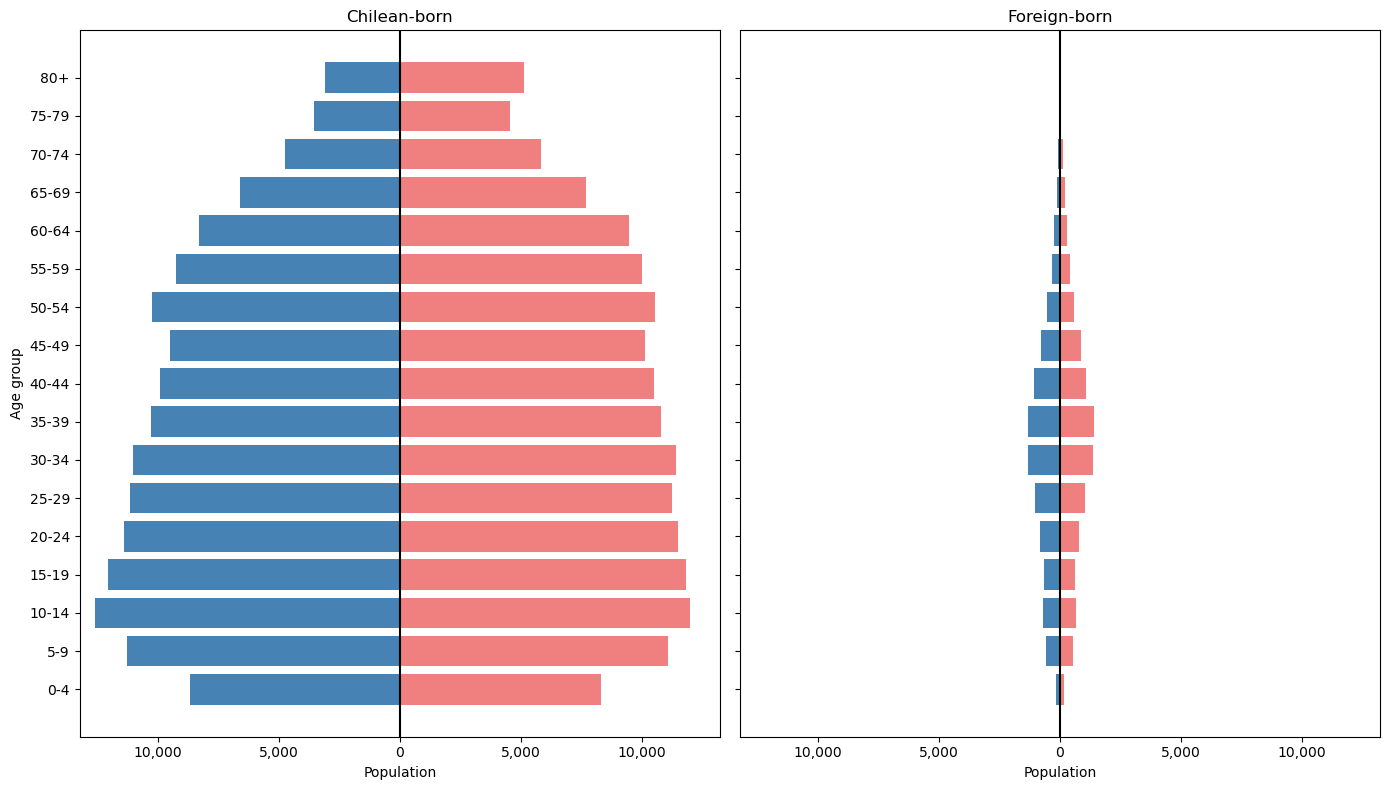

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

#Chilenos
ax = axes[0]
ax.barh(labels, -male_chile, label="Male", color="steelblue")
ax.barh(labels, female_chile, label="Female", color="lightcoral")
ax.axvline(0, color="black")
ax.set_title("Chilean-born")
ax.set_xlabel("Population")

#Extranjeros
ax = axes[1]
ax.barh(labels, -male_foreign, label="Male", color="steelblue")
ax.barh(labels, female_foreign, label="Female", color="lightcoral")
ax.axvline(0, color="black")
ax.set_title("Foreign-born")
ax.set_xlabel("Population")

max_x = max(
    male_chile.max(), female_chile.max(),
    male_foreign.max(), female_foreign.max())
for ax in axes:
    ax.set_xlim(-max_x * 1.05, max_x * 1.05)

#Eje X positivos en ambos
for ax in axes:
    xticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(int(x)):,}" for x in xticks])

axes[0].set_ylabel("Age group")
plt.tight_layout()

plt.show()

Con las series ya construidas, se graficó la pirámide poblacional separando en dos paneles: uno para la población **chilena** y otro para la **extranjera**. En ambos casos, los hombres se ubicaron al lado izquierdo y las mujeres al lado derecho, manteniendo la misma escala para que la comparación fuera directa y no se distorsionara visualmente.

El resultado muestra una diferencia bien clara entre ambos grupos. La población chilena tiene una estructura mucho más amplia en casi todos los tramos de edad, con mayor peso en edades jóvenes y adultas. En cambio, la población extranjera es bastante menor en tamaño y se concentra principalmente en edades laborales, sobre todo entre los 20 y 40 años. Esto sugiere que la población migrante presente en las comunas analizadas está compuesta en gran parte por personas en etapa activa, mientras que la población chilena refleja una estructura demográfica más completa y diversa en edades.

In [12]:
tabla_piramide = pd.DataFrame({
    "Male - Chilean":male_chile.values,
    "Male - Foreign":male_foreign.values,
    "Female - Chilean":female_chile.values,
    "Female - Foreign":female_foreign.values,}
    ,index=labels)

tabla_piramide

,Male - Chilean,Male - Foreign,Female - Chilean,Female - Foreign
0-4,8683,172,8313,178
5-9,11263,558,11066,554
10-14,12596,680,11986,649
15-19,12060,671,11819,618
20-24,11385,823,11501,805
25-29,11131,1042,11231,1055
30-34,11023,1323,11400,1354
35-39,10264,1332,10778,1396
40-44,9892,1053,10496,1094
45-49,9497,764,10124,870


- Como complemento para la pirámide, también se armó una tabla con los conteos de población en cada tramo de edad, separados por sexo y por condición de nacionalidad. Así, en vez de ver solo la forma del gráfico, también se pueden revisar los valores exactos detrás de cada barra.

## 1.2 Dependency Ratio

In [ ]:
##Sacamos las edades invalidas
dep = df[df["edad"] != -99].copy()

#Grupos por dependencia
dep["grupo_dep"] = pd.cut(dep["edad"],bins=[0, 15, 65, 200],labels=["0-14", "15-64", "65+"],right=False)

#Conteo de personas por comuna y grupo
tabla_dep = (dep.groupby(["nombre_comuna", "grupo_dep"]).size().unstack(fill_value=0).reset_index())

#Dependency ratio
tabla_dep["dependency_ratio"] = ((tabla_dep["0-14"] + tabla_dep["65+"]) / tabla_dep["15-64"])

dependency_table = tabla_dep
dependency_table

C:\Users\gusta\AppData\Local\Temp\ipykernel_40172\1428250365.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_dep = (dep.groupby(["nombre_comuna", "grupo_dep"]).size().unstack(fill_value=0).reset_index())


grupo_dep,nombre_comuna,0-14,15-64,65+,dependency_ratio
0,Alhué,1611,5146,1011,0.509522
1,El Monte,7528,24958,5011,0.502404
2,Huechuraba,19459,70891,11458,0.436120
3,La Pintana,35740,117380,22301,0.494471
4,María Pinto,2900,10086,2366,0.522110


Aquí se calculó la **razón de dependencia** para cada comuna, usando la relación entre la población potencialmente dependiente y la población en edad de trabajar. Para eso, primero se excluyeron las edades inválidas (`-99`) y luego se clasificó a las personas en tres grupos: **0–14 años**, **15–64 años** y **65 o más**.

Con esos grupos, se contó cuántas personas había en cada tramo por comuna y luego se aplicó la fórmula de la razón de dependencia: población de **0–14** más población de **65+**, todo dividido por la población de **15–64**. Los resultados muestran valores relativamente parecidos entre comunas, en general cercanos a **0,44–0,52**, lo que indica que por cada persona dependiente hay aproximadamente dos personas en edad activa. Dentro del grupo analizado, **Alhué, María Pinto y Huechuraba** presentan razones algo más altas, mientras que **Huechuraba** muestra la más baja.

## 1.3 Household size distribution

En este punto se calculó el tamaño de los hogares contando cuántas personas comparten la misma combinación de `id_vivienda` e `id_hogar`. Luego, cada hogar se clasificó según su composición de nacionalidad: **All Chilean** si todos sus integrantes eran chilenos, o **Has Foreign** si al menos una persona del hogar era extranjera. Además, los tamaños más grandes se agruparon en la categoría **8+**.

El gráfico muestra que la mayor parte de los hogares se concentra entre **2 y 4 personas**, tanto en los hogares de solo chilenos como en aquellos con presencia extranjera. También se ve que los hogares “All Chilean” son mucho más numerosos en términos absolutos, lo que era esperable dado su mayor peso dentro de la población total. Aun así, en ambos grupos se repite algo parecido.

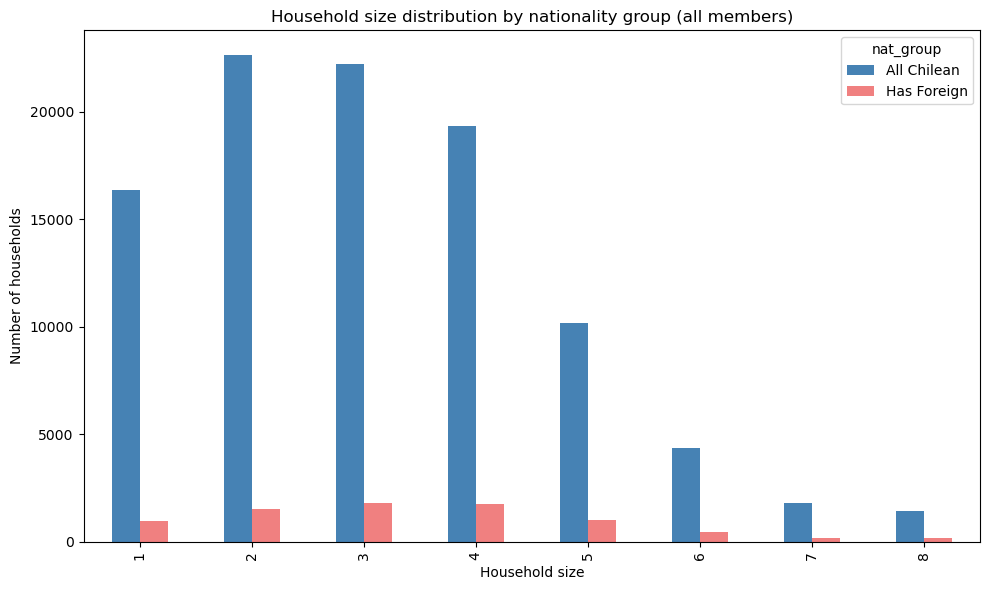

In [ ]:
#Nos quedamos con una fila por persona
base = df.drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

#Excluir nacionalidad missing
base = base[base["p27_nacionalidad_rec"] != -99].copy()

#Tamaño del hogar = personas por (id_vivienda, id_hogar)
hh_size = (base.groupby(["id_vivienda", "id_hogar"]).size().rename("hh_size").reset_index())

# clasificar hogares por composición de nacionalidad (todos los miembros)
# True si el hogar tiene al menos 1 persona Extranjera
hh_group = (base.groupby(["id_vivienda", "id_hogar"])["p27_nacionalidad_rec"].apply(lambda s: (s == 2).any()).rename("has_foreign").reset_index())
hh = hh_size.merge(hh_group, on=["id_vivienda", "id_hogar"], how="left")
hh["nat_group"] = hh["has_foreign"].map({False: "All Chilean", True: "Has Foreign"})

hh["hh_size_bin"] = hh["hh_size"].clip(upper=8)

#Distribución (conteo de hogares)
dist = (hh.groupby(["hh_size_bin", "nat_group"]).size().unstack(fill_value=0).sort_index())

#Gráfico
dist.plot(kind="bar", color={"All Chilean": "steelblue", "Has Foreign": "lightcoral"}, figsize=(10, 6))
plt.xlabel("Household size")
plt.ylabel("Number of households")
plt.title("Household size distribution by nationality group (all members)")
plt.tight_layout()
plt.show()

## 1.4 Education and Employment

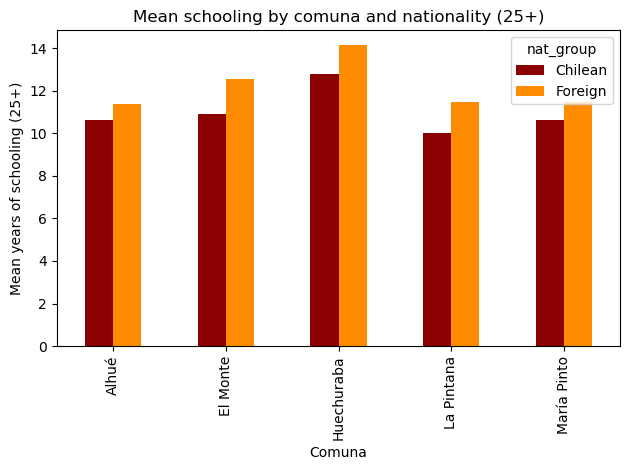

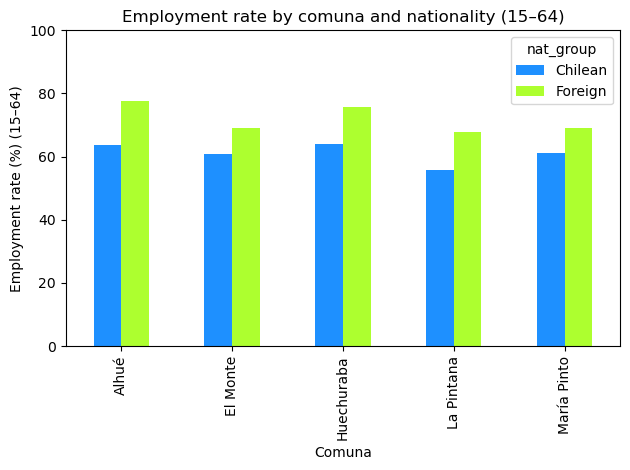

In [ ]:
base = df[
    (df["p27_nacionalidad_rec"] != -99) &
    (df["edad"] != -99)].drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

#Mean years of schooling, edad 25+
educación = base[
    (base["edad"] >= 25) &
    (base["escolaridad"] != -99)].copy()

educ_summary = (educación.groupby(["nombre_comuna", "p27_nacionalidad_rec"])["escolaridad"].mean().reset_index(name="mean_schooling"))

#Employment rate, edad 15-64
Empleo = base[
    (base["edad"] >= 15) & (base["edad"] <= 64) &
    (base["sit_fuerza_trabajo"] != -99)].copy()

EMPLOYED_CODES = {1}  # si es 1 significa ocupado
Empleo["is_employed"] = Empleo["sit_fuerza_trabajo"].isin(EMPLOYED_CODES).astype(int)

emp_summary = (Empleo.groupby(["nombre_comuna", "p27_nacionalidad_rec"])["is_employed"].mean().reset_index(name="employment_rate"))

summary = educ_summary.merge(emp_summary,on=["nombre_comuna", "p27_nacionalidad_rec"],how="outer")

summary["nat_group"] = summary["p27_nacionalidad_rec"].map({1: "Chilean", 2: "Foreign"})

edu_piv = summary.pivot(index="nombre_comuna", columns="nat_group", values="mean_schooling").sort_index()
emp_piv = summary.pivot(index="nombre_comuna", columns="nat_group", values="employment_rate").sort_index()

#Gráfico 1: escolaridad
edu_piv.plot(kind="bar", color=["darkred", "darkorange"])
plt.ylabel("Mean years of schooling (25+)")
plt.xlabel("Comuna")
plt.title("Mean schooling by comuna and nationality (25+)")
plt.tight_layout()
plt.show()

#Gráfico 2: empleo en % 
(emp_piv * 100).plot(kind="bar", color=["dodgerblue", "greenyellow"])
plt.ylabel("Employment rate (%) (15–64)")
plt.xlabel("Comuna")
plt.title("Employment rate by comuna and nationality (15–64)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

En este punto se compararon dos indicadores entre comunas y por grupo de nacionalidad: los **años promedio de escolaridad** para la población de **25 años o más**, y la **tasa de empleo** para la población entre **15 y 64 años**. Para ambos casos se trabajó solo con registros válidos, excluyendo edades, escolaridad o situación laboral marcadas como faltante.

Los gráficos muestran un patrón bastante consistente: en las 5 comunas analizadas, la población **extranjera** presenta en promedio **más años de escolaridad** que la población chilena, y además registra una **tasa de empleo mayor**. También se observan diferencias entre comunas. Por ejemplo, **Huechuraba** destaca con los niveles más altos tanto en escolaridad como en empleo, mientras que **La Pintana** aparece más abajo en ambos. Sugiriendo que la población extranjera presente en estas comunas no solo está más concentrada en edades activas(Fuerza de trabajo), sino que además muestra una inserción laboral ligeramente más fuerte y un nivel educativo en promedio un poco más alto que el de la población chilena.

- Como apoyo a los gráficos, también se generaron dos tablas resumen. La primera muestra los **años promedio de escolaridad** para la población, separados por comuna y por grupo de nacionalidad. La segunda presenta la **tasa de empleo** para la población, calculada como la proporción de personas ocupadas de cada grupo(Chilenos o extranjeros).

In [16]:
edu = df[
    (df["edad"] != -99) &
    (df["edad"] >= 25) &
    (df["escolaridad"] != -99) &
    (df["p27_nacionalidad_rec"] != -99)].drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

edu["nat_group"] = edu["p27_nacionalidad_rec"].map({1: "Chilean", 2: "Foreign"})

edu_summary = (edu.groupby(["nombre_comuna", "nat_group"])["escolaridad"].mean().reset_index(name="mean_schooling"))

edu_summary

,nombre_comuna,nat_group,mean_schooling
0,Alhué,Chilean,10.596439
1,Alhué,Foreign,11.376325
2,El Monte,Chilean,10.904782
3,El Monte,Foreign,12.531343
4,Huechuraba,Chilean,12.773288
5,Huechuraba,Foreign,14.123670
6,La Pintana,Chilean,10.012210
7,La Pintana,Foreign,11.472633
8,María Pinto,Chilean,10.600078
9,María Pinto,Foreign,11.465000


In [ ]:
work = df[
    (df["edad"] != -99) &
    (df["edad"] >= 15) & (df["edad"] <= 64) &
    (df["sit_fuerza_trabajo"] != -99) &
    (df["p27_nacionalidad_rec"] != -99)].drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

work["nat_group"] = work["p27_nacionalidad_rec"].map({1: "Chilean", 2: "Foreign"})
work["is_employed"] = (work["sit_fuerza_trabajo"] == 1).astype(int)

emp_summary = (work.groupby(["nombre_comuna", "nat_group"])["is_employed"].mean().reset_index(name="employment_rate"))

emp_summary

,nombre_comuna,nat_group,employment_rate
0,Alhué,Chilean,0.637849
1,Alhué,Foreign,0.775172
2,El Monte,Chilean,0.607493
3,El Monte,Foreign,0.691375
4,Huechuraba,Chilean,0.639157
5,Huechuraba,Foreign,0.758027
6,La Pintana,Chilean,0.557072
7,La Pintana,Foreign,0.676801
8,María Pinto,Chilean,0.610828
9,María Pinto,Foreign,0.692000


## 2.1 Percentege foreign-born by comuna

En este punto se calculó el porcentaje de población extranjera en cada comuna, considerando solo registros válidos y evitando duplicar personas en caso de que el `join` hubiera repetido observaciones. Para eso, primero se creó una variable indicadora que toma valor 1 cuando la persona es extranjera y 0 en caso contrario, y luego se obtuvo el promedio de esa variable por comuna. Al multiplicar ese promedio por 100, se obtiene directamente el porcentaje de residentes extranjeros.

Tanto la tabla como el gráfico muestran diferencias claras entre comunas. **Alhué** aparece con el porcentaje más alto de población extranjera, con un valor cercano a **11,3%**, seguida por **Huechuraba** con un **8%**. Más abajo quedan **La Pintana**, **El Monte** y **María Pinto**, con proporciones bastante menores. Sugiriendo que la población extranjera se concentra más en algunas comunas mas que en otras.

In [18]:
base = df[df["p27_nacionalidad_rec"] != -99].drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

foreign_table = (base.assign(is_foreign=(base["p27_nacionalidad_rec"] == 2).astype(int))
        .groupby("nombre_comuna")["is_foreign"].mean().mul(100)
        .reset_index(name="%_foreign").sort_values("%_foreign", ascending=False))

foreign_table["%_foreign"] = foreign_table["%_foreign"].round(2)
foreign_table

,nombre_comuna,%_foreign
0,Alhué,11.34
2,Huechuraba,8.28
3,La Pintana,4.44
1,El Monte,2.45
4,María Pinto,2.08


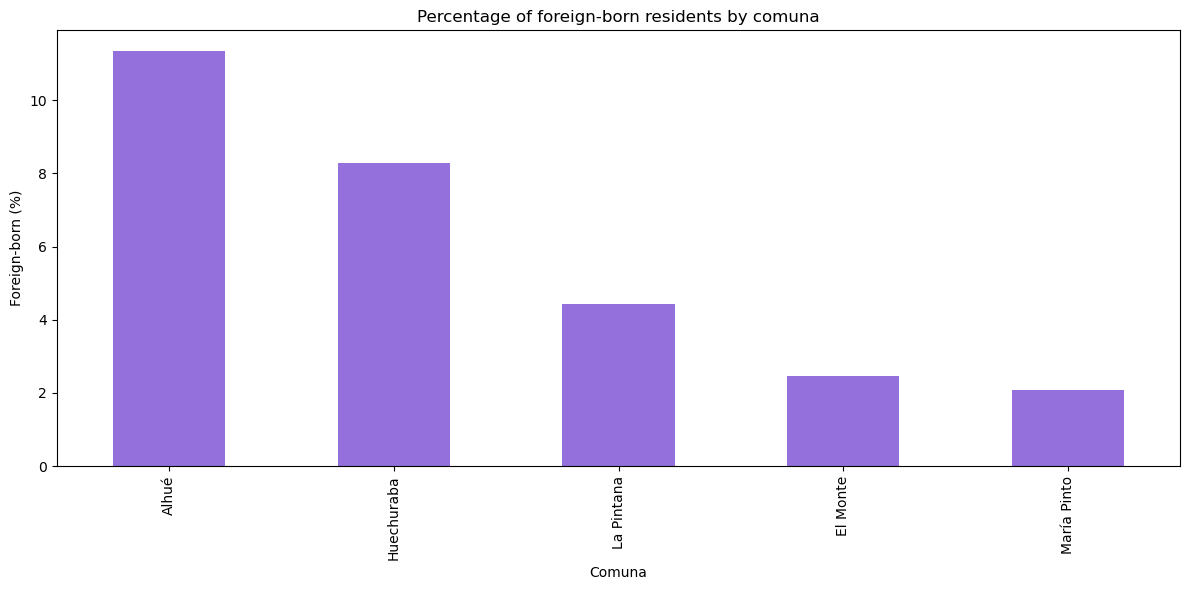

In [19]:
foreign_table.set_index("nombre_comuna")["%_foreign"].plot(kind="bar", color="mediumpurple", figsize=(12, 6))
plt.ylabel("Foreign-born (%)")
plt.xlabel("Comuna")
plt.title("Percentage of foreign-born residents by comuna")
plt.tight_layout()
plt.show()

## 2.2 Top Nacionalities

En este punto se identificaron las nacionalidades más frecuentes dentro de la población extranjera de las comunas analizadas. Para eso, primero se filtraron solo las personas extranjeras y se excluyeron los casos sin respuesta o con valor anonimizado. Luego, usando el diccionario de códigos territoriales específicos, se transformaron los códigos de nacionalidad en nombres de países o territorios para que el resultado fuera más interpretable.

La tabla y el gráfico muestran una concentración bastante marcada en unas pocas nacionalidades. **Venezuela** aparece con mucha diferencia como la nacionalidad más frecuente, seguida por **Perú**, **Colombia** y **Haití**. Más abajo aparecen Bolivia, Argentina y otros grupos más agregados, como “otros países de América del Sur”. Indicando que la población extranjera presente en las comunas proviene principalmente de países latinoamericanos, Pero con mayor presencia de la migración venezolana.

In [20]:
base = df[
    (df["p27_nacionalidad_rec"] == 2) &
    (df["p27_nacionalidad_esp"] != -99) &
    (df["p27_nacionalidad_esp"] != -66)
].drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()
    
top10_codes = base["p27_nacionalidad_esp"].value_counts().head(10)
top10_codes

p27_nacionalidad_esp
862    6597
604    3909
170    2177
332    1764
5      1153
68      941
32      720
13      475
150     231
142     186
Name: count, dtype: int64

In [21]:
xls = pd.ExcelFile("diccionario_variables_censo2024.xlsx")
print(xls.sheet_names)

dic_paises = pd.read_excel("diccionario_variables_censo2024.xlsx", sheet_name="cod_territoriales_especificos")
dic_paises

dic_paises.columns

['tabla_viviendas', 'tabla_hogares', 'tabla_personas', 'cod_territoriales_especificos', 'codigos_territoriales']


Index(['Código específico', 'Territorio específico'], dtype='object')

   codigo  count                                         pais
9     142    186                                         Asia
8     150    231                                       Europa
7      13    475  Otros países de América Central y El Caribe
6      32    720                                    Argentina
5      68    941            Bolivia (Estado Plurinacional de)
4       5   1153              Otros países de América del Sur
3     332   1764                                        Haití
2     170   2177                                     Colombia
1     604   3909                                         Perú
0     862   6597         Venezuela (República Bolivariana de)


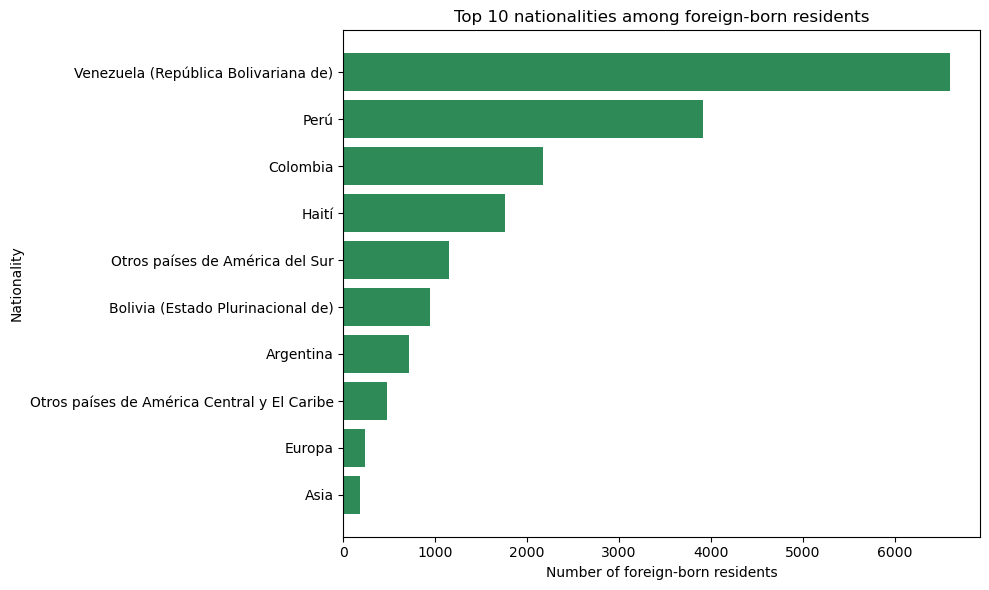

In [ ]:
#Filtrar solo extranjeros, excluyendo los que no responden o respuestas anonimas
base = df[
    (df["p27_nacionalidad_rec"] == 2) &
    (df["p27_nacionalidad_esp"] != -99) &
    (df["p27_nacionalidad_esp"] != -66)].drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

#Top 10(Nacionalidades)
top10_codes = base["p27_nacionalidad_esp"].value_counts().head(10)

#Carga del diccionario para los códigos y nombres de países
dic_paises = pd.read_excel("diccionario_variables_censo2024.xlsx",sheet_name="cod_territoriales_especificos")

# De código a país
mapping = dict(zip(dic_paises["Código específico"], dic_paises["Territorio específico"]))

top10_named = top10_codes.rename_axis("codigo").reset_index(name="count")
top10_named["pais"] = top10_named["codigo"].map(mapping)
top10_named = top10_named.sort_values("count")

print(top10_named)

#Grafica
plt.figure(figsize=(10, 6))
plt.barh(top10_named["pais"], top10_named["count"], color="seagreen")
plt.xlabel("Number of foreign-born residents")
plt.ylabel("Nationality")
plt.title("Top 10 nationalities among foreign-born residents")
plt.tight_layout()
plt.show()

## 2.3 Migration Status: Residence 5 years ago

En este punto se analizó dónde vivían las personas hace cinco años, usando la variable `p24_lug_resid5` y excluyendo tanto las edades inválidas como los menores de 5 años, ya que para ellos la pregunta no aplica. A partir de esa información se construyeron cuatro categorías: quienes vivían en la **misma comuna**, en una **comuna distinta de la misma región**, en una **región distinta** y en el **extranjero**. Luego se calculó el peso porcentual de cada grupo dentro de cada comuna.


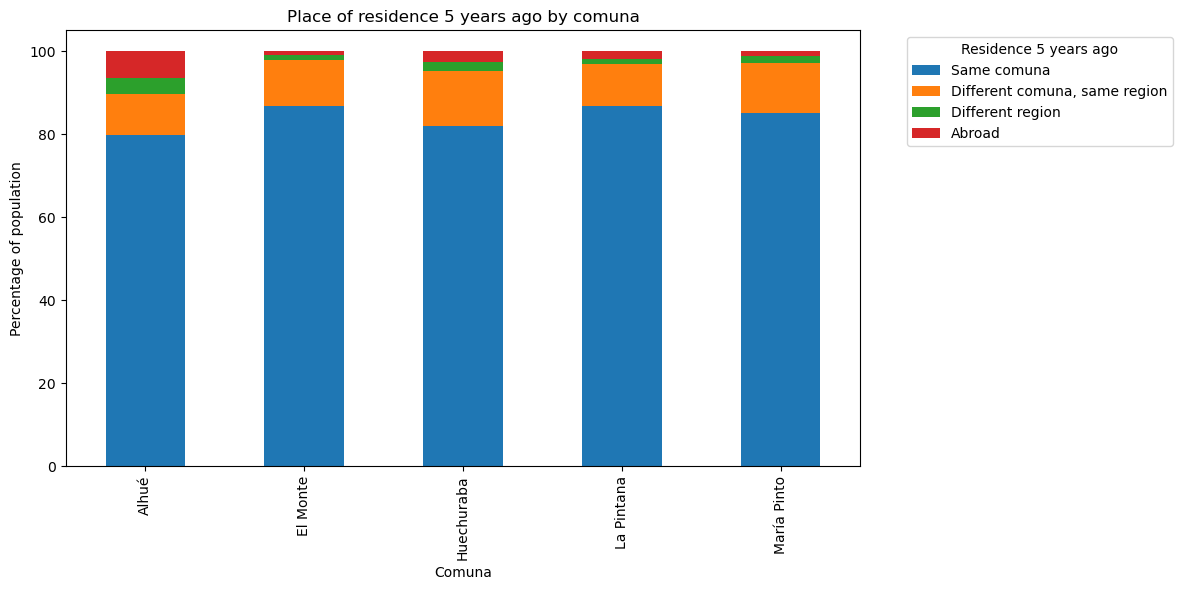

In [ ]:
#Base
base = df[
    (df["edad"] != -99) &
    (df["edad"] >= 5) &
    (df["p24_lug_resid5"] != -99)].drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()
base["comuna_str"] = base["comuna"].astype(str).str.zfill(5)
base["resid5_esp_str"] = base["p24_lug_resid5_esp"].astype(str).str.zfill(5)

#Región actual y hace 5 años
base["region_actual"] = base["comuna_str"].str[:2]
base["region_resid5"] = base["resid5_esp_str"].str[:2]

#Grupo migratorio
base["mig_group"] = None
base.loc[base["p24_lug_resid5"] == 2, "mig_group"] = "Same comuna"
base.loc[base["p24_lug_resid5"] == 4, "mig_group"] = "Abroad"
base.loc[(base["p24_lug_resid5"] == 3) &(base["region_actual"] == base["region_resid5"]),"mig_group"] = "Different comuna, same region"
base.loc[(base["p24_lug_resid5"] == 3) &(base["region_actual"] != base["region_resid5"]),"mig_group"] = "Different region"

# tabla porcentual por comuna
mig_table = (
    base.groupby(["nombre_comuna", "mig_group"]).size().groupby(level=0, group_keys=False).apply(lambda x: x / x.sum() * 100).reset_index(name="percentage"))

mig_piv = (mig_table.pivot(index="nombre_comuna", columns="mig_group", values="percentage").fillna(0))

#Orden de columnas
mig_piv = mig_piv[["Same comuna", "Different comuna, same region", "Different region", "Abroad"]]

#Gráfico
mig_piv.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.ylabel("Percentage of population")
plt.xlabel("Comuna")
plt.title("Place of residence 5 years ago by comuna")
plt.legend(title="Residence 5 years ago", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

- El gráfico muestra un patrón bastante claro: en las cinco comunas, la gran mayoría de la población ya vivía en la **misma comuna** cinco años antes del censo. El segundo grupo más importante corresponde a personas que vivían en **otra comuna de la misma región**, mientras que los casos de residencia en **otra región** o en el **extranjero** son menores. Entre las comunas, **Alhué** parece tener una proporción algo más baja de residentes estables y una fracción relativamente mayor de personas que vivían fuera de la comuna o incluso fuera del país, mientras que comunas como **El Monte** y **La Pintana** muestran mas permanencia o población que se no se cambia demasiado de comuna.

## 2.4 Arrival Period of Inmigrants

Acá utilizamos la variable `p26_llegada_periodo` para analizar en que periodo llegaron los inmigrantes. Para eso, primero se eliminó cualquier posible duplicado de personas y se filtraron los casos con información válida, excluyendo faltantes o no respondidos. Después, se codificaron a intervalos de tiempo más fáciles de interpretar, desde **2023–2024** hasta **antes de 1990**, de la misma forma que el diccionario de las variables.

La tabla muestra que la mayor parte de las llegadas se concentra en los períodos más recientes, especialmente entre **2017 y 2019**, seguido por **2020–2022** y **2014–2016**. También hay una presencia importante de llegadas entre **2023 y 2024**, lo que sugiere que la inmigración en estas comunas sigue siendo un fenómeno bastante actual. En cambio, los grupos correspondientes a llegadas más antiguas, como **1990–1999** o **antes de 1990**, son bastante menores.

In [24]:
base = df.drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

## Excluimos personas sin info de llegada
base = base[base["p26_llegada_periodo"].notna() & (base["p26_llegada_periodo"] != -99)].copy()

mapping_arrival = {
    1: "2023-2024",
    2: "2020-2022",
    3: "2017-2019",
    4: "2014-2016",
    5: "2010-2013",
    6: "2000-2009",
    7: "1990-1999",
    8: "Before 1990"}

arrival_table = (base["p26_llegada_periodo"].value_counts().sort_index().rename_axis("codigo").reset_index(name="count"))

arrival_table["periodo"] = arrival_table["codigo"].map(mapping_arrival)

arrival_table

,codigo,count,periodo
0,1.0,2173,2023-2024
1,2.0,4261,2020-2022
2,3.0,5467,2017-2019
3,4.0,3075,2014-2016
4,5.0,1728,2010-2013
5,6.0,2072,2000-2009
6,7.0,799,1990-1999
7,8.0,433,Before 1990


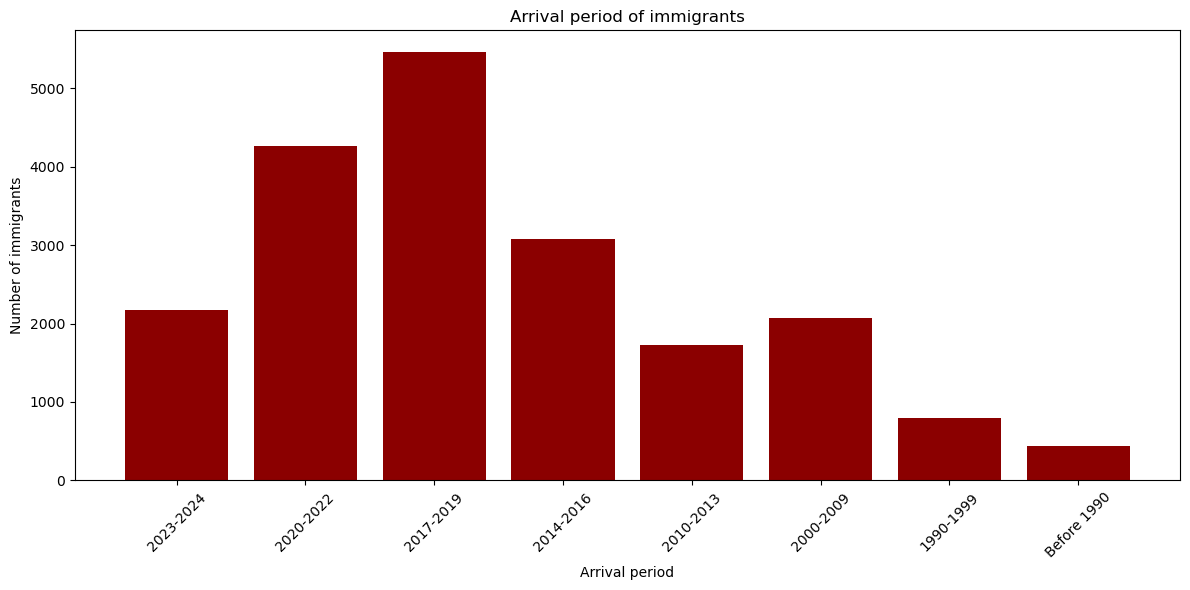

In [25]:
plt.figure(figsize=(12, 6))
plt.bar(arrival_table["periodo"], arrival_table["count"], color="darkred")
plt.xlabel("Arrival period")
plt.ylabel("Number of immigrants")
plt.title("Arrival period of immigrants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.1 Choropleth map: population by comuna

Para este mapa se utilizó el shapefile de comunas y se hizo un `merge` con la población total calculada previamente a partir de la base consolidada. En vez de mostrar solo las comunas asignadas aisladas, se dejó el mapa completo como fondo en color neutro y luego se destacaron únicamente las comunas de interés con una escala de color según su población. Además, se ajustó el zoom a la zona relevante y se agregaron etiquetas con el nombre de cada comuna para facilitar la lectura.

El resultado permite comparar de manera visual el tamaño poblacional de las comunas asignadas. **La Pintana** destaca claramente como la comuna con mayor población dentro del grupo, seguida por **Huechuraba**. En cambio, **Alhué**, **María Pinto** y **El Monte** aparecen con valores bastante menores, lo que se refleja en tonos más claros. En conjunto, el mapa muestra que las comunas analizadas son bastante distintas entre sí en términos de tamaño poblacional.

In [26]:
comunas_gdf = gpd.read_file("Comunas/comunas.shp")

comunas_gdf.columns

Index(['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna',
       'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna',
       'Provincia', 'geometry'],
      dtype='object')

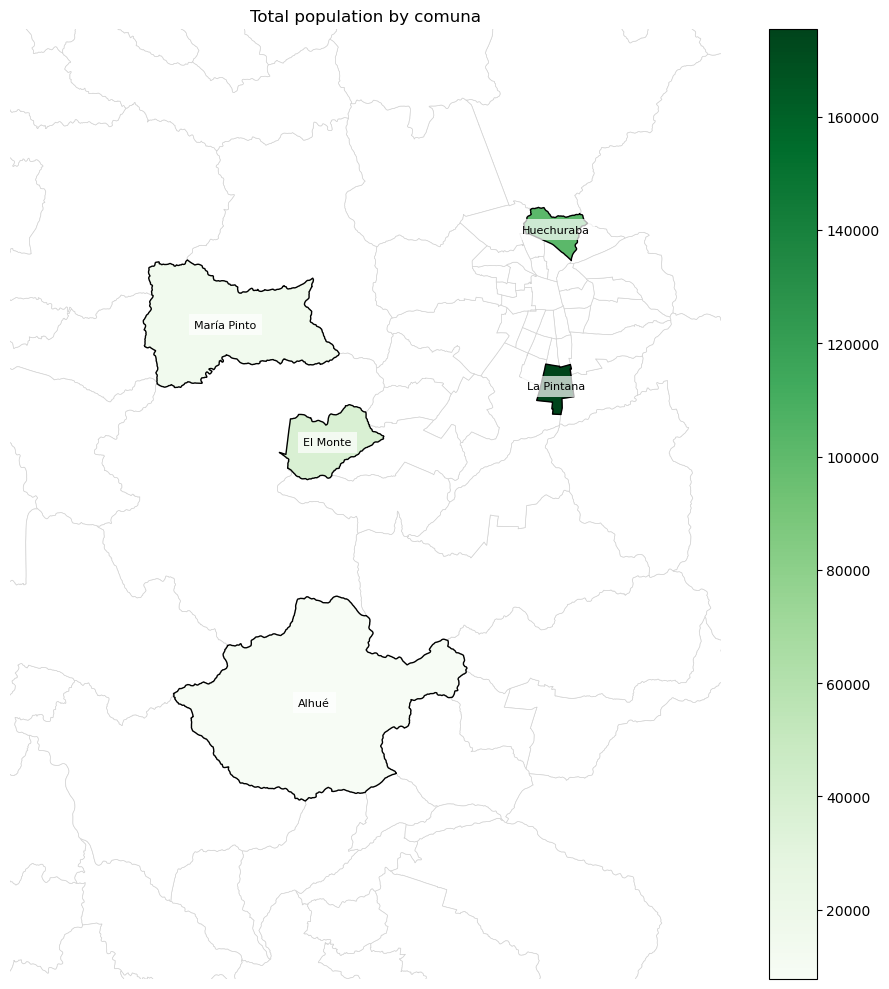

In [ ]:
#Población total por comuna
pob_comuna = (df.drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).groupby("comuna").size().reset_index(name="population"))

#Shapefile
comunas_gdf = gpd.read_file("Comunas/comunas.shp")
comunas_gdf["comuna"] = comunas_gdf["cod_comuna"].astype(int)

#Merge
map_gdf = comunas_gdf.merge(pob_comuna, on="comuna", how="left")

#Meter nuestras comunas
map_sel = map_gdf[map_gdf["comuna"].isin(OUR_COMUNAS)].copy()
fig, ax = plt.subplots(figsize=(10, 10))

#Todas las demas comunas en gris 
map_gdf.plot(ax=ax,color="white",edgecolor="lightgray",linewidth=0.5)

#Comunas nuestras en verde
map_sel.plot(column="population",cmap="Greens",legend=True,edgecolor="black",linewidth=1,ax=ax)

#Zoom
xmin, ymin, xmax, ymax = map_sel.total_bounds
xpad = (xmax - xmin) * 0.3
ypad = (ymax - ymin) * 0.3
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

#Etiquetas
map_sel["centroid"] = map_sel.geometry.centroid
for _, row in map_sel.iterrows():
    ax.text(
        row["centroid"].x,
        row["centroid"].y,
        row["Comuna"],   # nombre desde el shapefile
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

ax.set_title("Total population by comuna")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3.2 Choropleth map: % foreign-born by comuna

Para este segundo mapa se siguió una lógica similar al anterior, pero en vez de representar población total se usó el **porcentaje de población extranjera** en cada comuna. Primero se calculó ese porcentaje a partir de la base consolidada, y luego se hizo el `merge` con el shapefile de comunas para poder llevar esa información al espacio geográfico. Igual que en el mapa previo, se dejó el resto de las comunas como fondo neutro, se hizo zoom sobre el área relevante y se añadieron etiquetas para que la lectura fuera más clara.

El mapa muestra con bastante claridad que la presencia de población extranjera no se distribuye de manera homogénea entre las comunas analizadas. **Alhué** destaca con el porcentaje más alto, seguida por **Huechuraba**, mientras que **La Pintana**, **El Monte** y sobre todo **María Pinto** presentan valores menores. Esto refuerza lo que ya se veía en la tabla y en el gráfico de barras: aunque la población extranjera existe en todas las comunas estudiadas, su peso relativo cambia bastante entre comunas

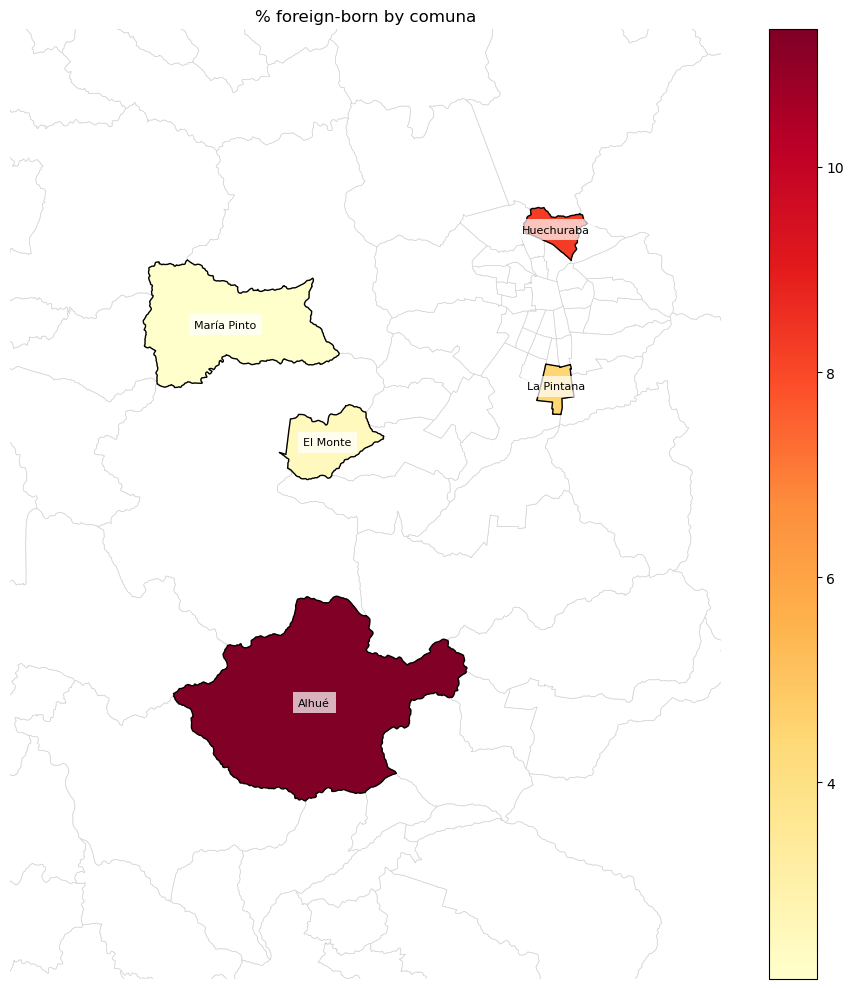

In [ ]:
# % foreign-born por comuna
foreign_comuna = (df[df["p27_nacionalidad_rec"] != -99]
      .drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"])
      .assign(pct_foreign=(df.loc[df["p27_nacionalidad_rec"] != -99, "p27_nacionalidad_rec"] == 2).astype(int))
      .groupby(["comuna", "nombre_comuna"])["pct_foreign"]
      .mean()
      .mul(100)
      .reset_index(name="pct_foreign"))

#Shapefile
comunas_gdf = gpd.read_file("Comunas/comunas.shp")
comunas_gdf["comuna"] = comunas_gdf["cod_comuna"].astype(int)

#Merge de nuevo
map_gdf = comunas_gdf.merge(foreign_comuna, on="comuna", how="left")

#Nuestras comunas
map_sel = map_gdf[map_gdf["comuna"].isin(OUR_COMUNAS)].copy()

fig, ax = plt.subplots(figsize=(10, 10))

#Las demas comunas en gris
map_gdf.plot(ax=ax,color="white",edgecolor="lightgray",linewidth=0.5)

#Nuestras comunas coloreadas
map_sel.plot(column="pct_foreign",cmap="YlOrRd",legend=True,edgecolor="black",linewidth=1,ax=ax)

#Zoom
xmin, ymin, xmax, ymax = map_sel.total_bounds
xpad = (xmax - xmin) * 0.3
ypad = (ymax - ymin) * 0.3
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

#Etiquetas
map_sel["centroid"] = map_sel.geometry.centroid
for _, row in map_sel.iterrows():
    ax.text(
        row["centroid"].x,
        row["centroid"].y,
        row["Comuna"],
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

ax.set_title("% foreign-born by comuna")
ax.axis("off")
plt.tight_layout()
plt.show()

## Part 4: Comuna-Level Summary Table (1 pt)


En esta última parte se construyó una **tabla resumen a nivel de comuna**, dejando una sola fila por cada una de las comunas analizadas. Para eso, primero se eliminó cualquier posible duplicación de personas y luego se definió una función (`build_summary`) que calcula, para cada comuna, un conjunto de indicadores demográficos y socioeconómicos.

La función reúne en una sola salida varias medidas que ya se habían trabajado por separado a lo largo de la tarea: población total, población chilena y extranjera, porcentaje de extranjeros, edad mediana por grupo, escolaridad promedio en mayores de 25 años, tasa de empleo entre 15 y 64 años y razón de dependencia. En todos los casos se excluyeron los valores faltantes (`-99`) para no contaminar los resultados.

Después, esa función se aplicó automáticamente a cada comuna usando `groupby("comuna")`, lo que permitió generar una tabla final compacta y comparable entre territorios. Por último, se redondearon las columnas principales para dejar el resultado más ordenado y fácil de leer. Esta tabla resume en un solo lugar los indicadores más importantes del análisis y funciona como síntesis general de la tarea.

In [ ]:
#Base
base = df.drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

def build_summary(g):
    out = {}

    out["codigo_comuna"] = g["comuna"].iloc[0]
    out["nombre_comuna"] = g["nombre_comuna"].iloc[0]

    #Población total
    out["pop_total"] = len(g)

    #Población chilena / extranjera
    g_nat = g[g["p27_nacionalidad_rec"] != -99].copy()
    out["pop_chilean"] = (g_nat["p27_nacionalidad_rec"] == 1).sum()
    out["pop_foreign"] = (g_nat["p27_nacionalidad_rec"] == 2).sum()

    if len(g_nat) > 0:
        out["pct_foreign"] = (out["pop_foreign"] / len(g_nat)) * 100
    else:
        out["pct_foreign"] = None

    #Edad mediana
    g_age = g[g["edad"] != -99].copy()

    age_chilean = g_age[g_age["p27_nacionalidad_rec"] == 1]["edad"]
    age_foreign = g_age[g_age["p27_nacionalidad_rec"] == 2]["edad"]

    out["median_age_chilean"] = age_chilean.median() if len(age_chilean) > 0 else None
    out["median_age_foreign"] = age_foreign.median() if len(age_foreign) > 0 else None

    #Escolaridad promedio
    g_edu = g[(g["edad"] != -99) &(g["edad"] >= 25) &(g["escolaridad"] != -99)].copy()

    edu_chilean = g_edu[g_edu["p27_nacionalidad_rec"] == 1]["escolaridad"]
    edu_foreign = g_edu[g_edu["p27_nacionalidad_rec"] == 2]["escolaridad"]

    out["mean_schooling_chilean"] = edu_chilean.mean() if len(edu_chilean) > 0 else None
    out["mean_schooling_foreign"] = edu_foreign.mean() if len(edu_foreign) > 0 else None

    #Tasa de empleo (15-64)
    g_work = g[
        (g["edad"] != -99) &
        (g["edad"] >= 15) & (g["edad"] <= 64) &
        (g["sit_fuerza_trabajo"] != -99)].copy()

    work_chilean = g_work[g_work["p27_nacionalidad_rec"] == 1]
    work_foreign = g_work[g_work["p27_nacionalidad_rec"] == 2]

    out["emp_rate_chilean"] = (
        (work_chilean["sit_fuerza_trabajo"] == 1).mean() * 100
        if len(work_chilean) > 0 else None)

    out["emp_rate_foreign"] = (
        (work_foreign["sit_fuerza_trabajo"] == 1).mean() * 100
        if len(work_foreign) > 0 else None)

    #Dependency ratio (overall)
    dep = g[g["edad"] != -99]["edad"]

    pop_0_14 = ((dep >= 0) & (dep <= 14)).sum()
    pop_15_64 = ((dep >= 15) & (dep <= 64)).sum()
    pop_65_plus = (dep >= 65).sum()

    out["dependency_ratio"] = (((pop_0_14 + pop_65_plus) / pop_15_64)
        if pop_15_64 > 0 else None)
    return pd.Series(out)

summary = base.groupby("comuna").apply(build_summary).reset_index(drop=True)

#Redondear algunas columnas
cols_round = [
    "pct_foreign",
    "median_age_chilean",
    "median_age_foreign",
    "mean_schooling_chilean",
    "mean_schooling_foreign",
    "emp_rate_chilean",
    "emp_rate_foreign",
    "dependency_ratio"]

summary[cols_round] = summary[cols_round].round(2)

summary

C:\Users\gusta\AppData\Local\Temp\ipykernel_40172\1404625725.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = base.groupby("comuna").apply(build_summary).reset_index(drop=True)


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13107,Huechuraba,101808,92790,8381,8.28,36.0,35.0,12.77,14.12,63.92,75.80,0.44
1,13112,La Pintana,175421,166483,7732,4.44,34.0,32.0,10.01,11.47,55.71,67.68,0.49
2,13502,Alhué,7768,6871,879,11.34,37.0,28.0,10.60,11.38,63.78,77.52,0.51
3,13504,María Pinto,15352,14996,319,2.08,38.0,31.0,10.60,11.46,61.08,69.20,0.52
4,13602,El Monte,37497,36404,915,2.45,36.0,34.0,10.90,12.53,60.75,69.14,0.50


In [30]:
summary.to_csv("output_tarea1_comuna_summary.csv", index=False)

Finalmente este resumen hecho en el punto anterior es traspasado a un archivo csv